In [1]:
#initial import of relevant packages for graphing
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter
from rdkit import Chem
from rdkit.Chem import Descriptors
#https://stackoverflow.com/questions/32085531/importing-a-csv-file-into-python-to-make-scatterplots-and-histograms

In [3]:
#read in the data sheet (located externally, as the data is not mine to publish)
import pandas as pd

file_path = "/home/ari.ginsparg-umw/Complete_Dataset_ULTRAdatabase_v3.xls"

df = pd.read_excel(file_path, header=1)

df.head()

,ScreenLookup#,LIBRARY,Dead at end?,"DEAD, Sick or Half Dead",SERIOUSLY FLAWED PLATES,ADDITIONAL DEAD/Artifacts,at odds? Meaning the box and column values go in opposite directions.,Extra-Flawed to be flagged (these were noted mostly by hand),artifact flag (post-new sort),REMOVAL LIST,...,AVERAGE ACTIVITY/10 MINUTES.12,AVERAGE ACTIVITY/10 MINUTES.13,AVERAGE ACTIVITY/10 MINUTES.14,AVERAGE ACTIVITY/10 MINUTES.15,AVERAGE ACTIVITY/Active Minute.18,AVERAGE ACTIVITY/Active Minute.19,AVERAGE ACTIVITY/Active Minute.20,AVERAGE ACTIVITY/Active Minute.21,AVERAGE ACTIVITY/Active Minute.22,AVERAGE ACTIVITY/Active Minute.23
0,NaN,NaN,NaN,598,425.0,54.0,91.0,225.0,63.0,1178.0,...,night4,day5,night5,day6,night4,day5,night5,day6,DAY AVERAGE,NIGHT AVERAGE
1,1,Ion Channel Ligands,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.756276,0.052711,0.165262,0.045213,0.099383,0.212547,0.350023,0.446649,0.01393,NaN
2,2,Ion Channel Ligands,D,1,0.0,0.0,0.0,0.0,0.0,1.0,...,0.038696,0.013772,0.015706,0.0084,0.001515,0.006696,NaN,NaN,0.005181,NaN
3,3,Ion Channel Ligands,D,1,0.0,0.0,0.0,0.0,0.0,1.0,...,0.038726,0.013945,0.015872,0.008467,0.001258,0.03942,NaN,NaN,0.02967,NaN
4,4,Ion Channel Ligands,D,1,0.0,0.0,0.0,0.0,0.0,1.0,...,0.299156,0.025792,0.01575,0.008458,0.660686,0.011289,NaN,NaN,0.015603,NaN


In [5]:
#functions to sanitize and check for valid CAS numbers
import re
import pandas as pd
import numpy as np

def normalize_cas(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x == "" or x.lower() in {"nan", "none", "null"}:
        return None
    return x

def cas_checksum_valid(cas):
    """
    CAS format: up to 7 digits - 2 digits - 1 digit
    Example: 50-00-0
    """
    if cas is None:
        return False
    
    if not re.fullmatch(r"\d{2,7}-\d{2}-\d", cas):
        return False
    
    parts = cas.split("-")
    digits = "".join(parts[:-1])
    check_digit = int(parts[-1])
    
    total = 0
    for i, d in enumerate(reversed(digits), start=1):
        total += i * int(d)
    
    return (total % 10) == check_digit

In [11]:
CAS_COL = "CAS#"          # change if needed
#NAME_COL = "Drug Name"    # change if needed



#sanitize

df_work = df.copy()

df_work[CAS_COL] = df_work[CAS_COL].apply(normalize_cas)
#df_work[NAME_COL] = df_work[NAME_COL].astype(str).str.strip()

df_work["cas_valid"] = df_work[CAS_COL].apply(cas_checksum_valid)

In [15]:
#test print
print(df_work["CAS#"])
print(df_work["cas_valid"])

0             None
1          Control
2       52665-69-7
3       30484-77-6
4        1951-25-3
           ...    
5767             9
5768             3
5769          3.25
5770       3694.25
5771          None
Name: CAS#, Length: 5772, dtype: object
0       False
1       False
2        True
3        True
4        True
        ...  
5767    False
5768    False
5769    False
5770    False
5771    False
Name: cas_valid, Length: 5772, dtype: bool


In [16]:
#remove bad CAS
df_keep = df_work[(df_work["cas_valid"])].copy()

print("Original rows:", len(df))
print("Rows with valid CAS and not obvious controls:", len(df_keep))

Original rows: 5772
Rows with valid CAS and not obvious controls: 4730


In [21]:
#removal check
df_excluded_initial = df_work[(~df_work["cas_valid"])].copy()
print(df_excluded_initial[[CAS_COL, "cas_valid"]].head(50))

        CAS#  cas_valid
0       None      False
1    Control      False
8    Control      False
9    Control      False
16   Control      False
17   Control      False
24   Control      False
25   Control      False
32   Control      False
33   Control      False
40   Control      False
41   Control      False
48   Control      False
49   Control      False
51     Empty      False
56   Control      False
57   Control      False
64   Control      False
65   Control      False
72   Control      False
73   Control      False
74      None      False
80   Control      False
82     BLANK      False
86     blank      False
99      None      False
123      T11      False
125     None      False
128     None      False
142     None      False
149     None      False
150     None      False
151     None      False
152     None      False
163     None      False
165     None      False
167     None      False
169     None      False
170     None      False
171     None      False
172     None    

In [22]:
#import my active CAS commonlibrary API key (can apply for one at https://www.cas.org/services/commonchemistry-api)
from pathlib import Path

api_key_path = Path("/home/ari.ginsparg-umw/cas_api_key.txt")
API_KEY = api_key_path.read_text().strip()

In [24]:
#function to pull the API data by cas number
import requests
import time

SESSION = requests.Session()
SESSION.headers.update({
    "X-API-KEY": API_KEY
})

def query_cas_common_chemistry(cas_rn, timeout=30):
    url = "https://commonchemistry.cas.org/api/detail"
    params = {"cas_rn": cas_rn}
    
    try:
        resp = SESSION.get(url, params=params, timeout=timeout)
        resp.raise_for_status()
        return resp.json(), None
    except requests.HTTPError as e:
        text = None
        try:
            text = resp.text
        except Exception:
            pass
        return None, f"HTTPError: {e}; response={text}"
    except Exception as e:
        return None, f"{type(e).__name__}: {e}"

In [25]:
#test on formaldehyde example
test_data, test_err = query_cas_common_chemistry("50-00-0")
print(test_err)
print(test_data)

None
{'uri': 'substance/pt/50000', 'rn': '50-00-0', 'name': 'Formaldehyde', 'images': ['<svg width="100" viewBox="0 0 100 15" style="fill-opacity:1; color-rendering:auto; color-interpolation:auto; text-rendering:auto; stroke:black; stroke-linecap:square; stroke-miterlimit:10; shape-rendering:auto; stroke-opacity:1; fill:black; stroke-dasharray:none; font-weight:normal; stroke-width:1; font-family:\'Open Sans\'; font-style:normal; stroke-linejoin:miter; font-size:12; stroke-dashoffset:0; image-rendering:auto;" height="15" class="cas-substance-image" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg"><svg class="cas-substance-single-component"><rect y="0" x="0" width="100" stroke="none" ry="7" rx="7" height="15" fill="white" class="cas-substance-group"/><svg y="0" x="30" width="40" viewBox="0 0 40 15" style="fill:black;" height="15" class="cas-substance-single-component-image"><svg><g><g transform="translate(18,9)" style="text-rendering:geometricPrecision; colo

In [26]:
#extract the structure data per cas number in the dataframe
def extract_cas_fields(api_json):
    if not api_json:
        return {
            "cas_api_name": None,
            "cas_api_smile": None,
            "cas_api_canonicalSmile": None,
            "cas_api_inchi": None,
        }
    
    return {
        "cas_api_name": api_json.get("name"),
        "cas_api_smile": api_json.get("smile"),
        "cas_api_canonicalSmile": api_json.get("canonicalSmile"),
        "cas_api_inchi": api_json.get("inchi"),
    }

results = []

unique_cas = df_keep[CAS_COL].dropna().astype(str).unique().tolist()

for i, cas_rn in enumerate(unique_cas, start=1):
    data, err = query_cas_common_chemistry(cas_rn)
    fields = extract_cas_fields(data)
    fields[CAS_COL] = cas_rn
    fields["cas_api_lookup_ok"] = data is not None
    fields["cas_api_error"] = err
    results.append(fields)
    
    if i % 25 == 0:
        print(f"Completed {i} / {len(unique_cas)}")
    
    time.sleep(0.1)  # gentle pacing

cas_results_df = pd.DataFrame(results)
cas_results_df.head()

Completed 25 / 2866
Completed 50 / 2866
Completed 75 / 2866
Completed 100 / 2866
Completed 125 / 2866
Completed 150 / 2866
Completed 175 / 2866
Completed 200 / 2866
Completed 225 / 2866
Completed 250 / 2866
Completed 275 / 2866
Completed 300 / 2866
Completed 325 / 2866
Completed 350 / 2866
Completed 375 / 2866
Completed 400 / 2866
Completed 425 / 2866
Completed 450 / 2866
Completed 475 / 2866
Completed 500 / 2866
Completed 525 / 2866
Completed 550 / 2866
Completed 575 / 2866
Completed 600 / 2866
Completed 625 / 2866
Completed 650 / 2866
Completed 675 / 2866
Completed 700 / 2866
Completed 725 / 2866
Completed 750 / 2866
Completed 775 / 2866
Completed 800 / 2866
Completed 825 / 2866
Completed 850 / 2866
Completed 875 / 2866
Completed 900 / 2866
Completed 925 / 2866
Completed 950 / 2866
Completed 975 / 2866
Completed 1000 / 2866
Completed 1025 / 2866
Completed 1050 / 2866
Completed 1075 / 2866
Completed 1100 / 2866
Completed 1125 / 2866
Completed 1150 / 2866
Completed 1175 / 2866
Complete

,cas_api_name,cas_api_smile,cas_api_canonicalSmile,cas_api_inchi,CAS#,cas_api_lookup_ok,cas_api_error
0,Calcimycin,C[C@H]1[C@]2(O[C@]([C@@H](C(=O)C3=CC=CN3)C)([C...,O=C(O)C1=C2N=C(OC2=CC=C1NC)CC3OC4(OC(C(C(=O)C5...,InChI=1S/C29H37N3O6/c1-15-10-11-29(17(3)13-16(...,52665-69-7,True,None
1,Flunarizine hydrochloride,C(N1CCN(C/C=C/C2=CC=CC=C2)CC1)(C3=CC=C(F)C=C3)...,Cl.FC1=CC=C(C=C1)C(C2=CC=C(F)C=C2)N3CCN(CC=CC=...,InChI=1S/C26H26F2N2.2ClH/c27-24-12-8-22(9-13-2...,30484-77-6,True,None
2,Amiodarone,,O=C(C1=CC(I)=C(OCCN(CC)CC)C(I)=C1)C=2C=3C=CC=C...,InChI=1S/C25H29I2NO3/c1-4-7-11-22-23(18-10-8-9...,1951-25-3,True,None
3,5-Hydroxydecanoic acid,,O=C(O)CCCC(O)CCCCC,InChI=1S/C10H20O3/c1-2-3-4-6-9(11)7-5-8-10(12)...,624-00-0,True,None
4,"Guanidine, <em>N</em>-cyano-<em>N</em>′-4-pyri...",,N#CNC(=NC=1C=CN=CC1)NC(C)C(C)(C)C.O,"InChI=1S/C13H19N5.H2O/c1-10(13(2,3)4)17-12(16-...",85371-64-8,True,None


In [28]:
#merge the cas results back into the main sanitized dataframe
df_merged = df_keep.merge(cas_results_df, on=CAS_COL, how="left")

print(df_merged.shape)
df_merged[[CAS_COL, "cas_api_name", "cas_api_canonicalSmile", "cas_api_inchi"]].head()

(4730, 222)


,CAS#,cas_api_name,cas_api_canonicalSmile,cas_api_inchi
0,52665-69-7,Calcimycin,O=C(O)C1=C2N=C(OC2=CC=C1NC)CC3OC4(OC(C(C(=O)C5...,InChI=1S/C29H37N3O6/c1-15-10-11-29(17(3)13-16(...
1,30484-77-6,Flunarizine hydrochloride,Cl.FC1=CC=C(C=C1)C(C2=CC=C(F)C=C2)N3CCN(CC=CC=...,InChI=1S/C26H26F2N2.2ClH/c27-24-12-8-22(9-13-2...
2,1951-25-3,Amiodarone,O=C(C1=CC(I)=C(OCCN(CC)CC)C(I)=C1)C=2C=3C=CC=C...,InChI=1S/C25H29I2NO3/c1-4-7-11-22-23(18-10-8-9...
3,624-00-0,5-Hydroxydecanoic acid,O=C(O)CCCC(O)CCCCC,InChI=1S/C10H20O3/c1-2-3-4-6-9(11)7-5-8-10(12)...
4,85371-64-8,"Guanidine, <em>N</em>-cyano-<em>N</em>′-4-pyri...",N#CNC(=NC=1C=CN=CC1)NC(C)C(C)(C)C.O,"InChI=1S/C13H19N5.H2O/c1-10(13(2,3)4)17-12(16-..."


In [45]:
#remove misses on the smiles determination
df_struct = df_merged[df_merged["cas_api_canonicalSmile"].notna()].copy()

print("Rows with returned canonicalSmile:", len(df_struct))

Rows with returned canonicalSmile: 4180


In [46]:
#failure inspection sanity check
df_failed = df_merged[df_merged["cas_api_canonicalSmile"].isna()].copy()
df_failed[[CAS_COL, "cas_api_error"]].head(30)

,CAS#,cas_api_error
8,33978-72-2,HTTPError: 404 Client Error: Not Found for url...
14,113317-61-6,HTTPError: 404 Client Error: Not Found for url...
21,121055-10-5,HTTPError: 404 Client Error: Not Found for url...
23,6151-40-2,HTTPError: 404 Client Error: Not Found for url...
31,97217-84-0,HTTPError: 404 Client Error: Not Found for url...
43,1166-01-4,HTTPError: 404 Client Error: Not Found for url...
44,147695-92-9,HTTPError: 404 Client Error: Not Found for url...
70,61129-30-4,HTTPError: 404 Client Error: Not Found for url...
85,98185-19-4,HTTPError: 404 Client Error: Not Found for url...
89,150323-78-7,HTTPError: 404 Client Error: Not Found for url...


In [32]:
#old function that does not attempt to recover ligands with formal charges or multicomponent compounds
"""
#check for and remove surviving molecule entries that are bad candidates for checking logp (like metal salts)
from rdkit import Chem
from rdkit.Chem import Descriptors

def analyze_smiles_for_clogp(smiles):
    result = {
        "rdkit_parse_ok": False,
        "is_multicomponent": None,
        "has_formal_charge": None,
        "num_fragments": None,
        "mol_logp": None,
        "clogp_usable": False,
        "clogp_exclusion_reason": None,
    }
    
    if pd.isna(smiles) or str(smiles).strip() == "":
        result["clogp_exclusion_reason"] = "missing_smiles"
        return result
    
    smiles = str(smiles).strip()
    result["is_multicomponent"] = "." in smiles
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        result["clogp_exclusion_reason"] = "rdkit_parse_failed"
        return result
    
    result["rdkit_parse_ok"] = True
    result["num_fragments"] = len(Chem.GetMolFrags(mol))
    
    formal_charge = sum(atom.GetFormalCharge() for atom in mol.GetAtoms())
    any_charge = any(atom.GetFormalCharge() != 0 for atom in mol.GetAtoms())
    result["has_formal_charge"] = any_charge
    
    if result["is_multicomponent"]:
        result["clogp_exclusion_reason"] = "multicomponent_salt_or_mixture"
        return result
    
    if any_charge:
        result["clogp_exclusion_reason"] = "formal_charge_present"
        return result
    
    try:
        result["mol_logp"] = Descriptors.MolLogP(mol)
        result["clogp_usable"] = True
        result["clogp_exclusion_reason"] = None
    except Exception:
        result["clogp_exclusion_reason"] = "MolLogP_failed"
    
    return result
"""

In [47]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
def analyze_smiles_for_clogp(smiles):
    """
    Analyze a SMILES string for cLogP suitability, with recovery attempts:
      1. Parse original SMILES
      2. If multicomponent, keep the largest organic fragment
      3. Attempt neutralization of recoverable formal charges
      4. Calculate MolLogP on the recovered/cleaned molecule if appropriate

    Returns a dict of flags, original/recovered SMILES, and logP result.
    """
    
    result = {
        # original input / parse state
        "original_smiles": None,
        "rdkit_parse_ok": False,
        "original_is_multicomponent": None,
        "original_num_fragments": None,
        "original_has_formal_charge": None,
        
        # recovery tracking
        "recovery_attempted": False,
        "recovery_actions": None,
        "recovered_smiles": None,
        "recovered_parse_ok": False,
        "recovered_has_formal_charge": None,
        "recovered_num_fragments": None,
        
        # final suitability / descriptor
        "mol_logp": None,
        "clogp_usable": False,
        "clogp_exclusion_reason": None,
    }
    
    if pd.isna(smiles) or str(smiles).strip() == "":
        result["clogp_exclusion_reason"] = "missing_smiles"
        return result
    
    smiles = str(smiles).strip()
    result["original_smiles"] = smiles
    result["original_is_multicomponent"] = "." in smiles
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        result["clogp_exclusion_reason"] = "rdkit_parse_failed"
        return result
    
    result["rdkit_parse_ok"] = True
    result["original_num_fragments"] = len(Chem.GetMolFrags(mol))
    result["original_has_formal_charge"] = any(atom.GetFormalCharge() != 0 for atom in mol.GetAtoms())
    
    working_mol = mol
    recovery_actions = []
    
    # --------------------------------------------------
    # Step 1: If multicomponent, keep the largest organic fragment
    # --------------------------------------------------
    if result["original_num_fragments"] > 1:
        result["recovery_attempted"] = True
        
        lfc = rdMolStandardize.LargestFragmentChooser(preferOrganic=True)
        largest_frag = lfc.choose(working_mol)
        
        if largest_frag is None:
            result["clogp_exclusion_reason"] = "fragment_recovery_failed"
            return result
        
        working_mol = largest_frag
        recovery_actions.append("largest_organic_fragment_selected")
    
    # --------------------------------------------------
    # Step 2: Attempt neutralization of recoverable charges
    # --------------------------------------------------
    # This is conservative: it fixes common protonation/deprotonation states
    # where a neutral parent is chemically sensible.
    uncharger = rdMolStandardize.Uncharger()
    uncharged_mol = uncharger.uncharge(working_mol)
    
    if uncharged_mol is not None:
        before_smiles = Chem.MolToSmiles(working_mol, canonical=True)
        after_smiles = Chem.MolToSmiles(uncharged_mol, canonical=True)
        
        if after_smiles != before_smiles:
            result["recovery_attempted"] = True
            recovery_actions.append("neutralized_formal_charge")
            working_mol = uncharged_mol
    
    # --------------------------------------------------
    # Step 3: Final recovered molecule checks
    # --------------------------------------------------
    recovered_smiles = Chem.MolToSmiles(working_mol, canonical=True)
    result["recovered_smiles"] = recovered_smiles
    
    recovered_mol = Chem.MolFromSmiles(recovered_smiles)
    if recovered_mol is None:
        result["clogp_exclusion_reason"] = "recovered_smiles_parse_failed"
        return result
    
    result["recovered_parse_ok"] = True
    result["recovered_num_fragments"] = len(Chem.GetMolFrags(recovered_mol))
    result["recovered_has_formal_charge"] = any(
        atom.GetFormalCharge() != 0 for atom in recovered_mol.GetAtoms()
    )
    
    result["recovery_actions"] = ";".join(recovery_actions) if recovery_actions else None
    
    # --------------------------------------------------
    # Step 4: Final decision for cLogP usability
    # --------------------------------------------------
    if result["recovered_num_fragments"] > 1:
        result["clogp_exclusion_reason"] = "still_multicomponent_after_recovery"
        return result
    
    if result["recovered_has_formal_charge"]:
        result["clogp_exclusion_reason"] = "still_formally_charged_after_recovery"
        return result
    
    try:
        result["mol_logp"] = Descriptors.MolLogP(recovered_mol)
        result["clogp_usable"] = True
        result["clogp_exclusion_reason"] = None
    except Exception:
        result["clogp_exclusion_reason"] = "MolLogP_failed"
    
    return result

In [48]:
smiles_analysis = df_struct["cas_api_canonicalSmile"].apply(analyze_smiles_for_clogp)
smiles_analysis_df = pd.DataFrame(smiles_analysis.tolist(), index=df_struct.index)

df_struct = pd.concat([df_struct, smiles_analysis_df], axis=1)

[14:11:53] Running Uncharger
[14:11:53] Running LargestFragmentChooser
[14:11:53] Fragment: Cl
[14:11:53] New largest fragment: Cl (2)
[14:11:53] Fragment: Fc1ccc(C(c2ccc(F)cc2)N2CCN(CC=Cc3ccccc3)CC2)cc1
[14:11:53] New largest fragment: Fc1ccc(C(c2ccc(F)cc2)N2CCN(CC=Cc3ccccc3)CC2)cc1 (56)
[14:11:53] Running Uncharger
[14:11:53] Running Uncharger
[14:11:53] Running Uncharger
[14:11:53] Running LargestFragmentChooser
[14:11:53] Fragment: CC(NC(=Nc1ccncc1)NC#N)C(C)(C)C
[14:11:53] New largest fragment: CC(NC(=Nc1ccncc1)NC#N)C(C)(C)C (37)
[14:11:53] Fragment: O
[14:11:53] Running Uncharger
[14:11:53] Running Uncharger
[14:11:53] Running Uncharger
[14:11:53] Running Uncharger
[14:11:53] Running Uncharger
[14:11:53] Running Uncharger
[14:11:53] Running LargestFragmentChooser
[14:11:53] Fragment: Cl
[14:11:53] New largest fragment: Cl (2)
[14:11:53] Fragment: CCN(CC)CCNC(=O)c1ccc(N)cc1
[14:11:53] New largest fragment: CCN(CC)CCNC(=O)c1ccc(N)cc1 (38)
[14:11:53] Running Uncharger
[14:11:53] Runn

[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: CS(=O)(=O)O
[14:11:54] New largest fragment: CS(=O)(=O)O (9)
[14:11:54] Fragment: CN1C2CCC1CC(OC(c1ccccc1)c1ccccc1)C2
[14:11:54] New largest fragment: CN1C2CCC1CC(OC(c1ccccc1)c1ccccc1)C2 (48)
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: Cl
[14:11:54] New largest fragment: Cl (2)
[14:11:54] Fragment: CC(C)CC(NC(=O)C(O)C(N)Cc1ccccc1)C(=O)O
[14:11:54] New largest fragment: CC(C)CC(NC(=O)C(O)C(N)Cc1ccccc1)C(=O)O (46)
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: Cc1ccc(S(=O)(=O)[O-])cc1
[14:11:54] New largest fragment: Cc1ccc(S(=O)(=O)[O-])cc1 (18)
[14:11:54] Fragment: CC[N+](C)(C)Cc1ccccc1Br
[14:11:54] New largest fragment: CC[N+](C)(C)Cc1ccccc1Br (30)
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] R

[14:11:54] New largest fragment: Cl (2)
[14:11:54] Fragment: OCCN1CCN(CCCN2c3ccccc3C=Cc3ccccc32)CC1
[14:11:54] New largest fragment: OCCN1CCN(CCCN2c3ccccc3C=Cc3ccccc32)CC1 (56)
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: [Na]
[14:11:54] New largest fragment: [Na] (1)
[14:11:54] Fragment: CC(=O)OC1CC2(C)C(CC(O)C3C4(C)CCC(O)C(C)C4CCC32C)C1=C(CCC=C(C)C)C(=O)O
[14:11:54] New largest fragment: CC(=O)OC1CC2(C)C(CC(O)C3C4(C)CCC(O)C(C)C4CCC32C)C1=C(CCC=C(C)C)C(=O)O (85)
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: Cl
[14:11:54] New largest fragment: Cl (2)
[14:11:54] Fragment: CNCCC(Oc1ccc(C(F)(F)F)cc1)c1ccccc1
[14:11:54] New largest fragment: CNCCC(Oc1ccc(C(F)(F)F)cc1)c1ccccc1 (40)
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: Cl
[14:11:54] New largest fragment: Cl (2)
[14:11:54] Fragment: COc1cccc(OC)c1OCCNCC1COc2ccccc2O1
[1

[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: O=C(O)C=CC(=O)O
[14:11:54] New largest fragment: O=C(O)C=CC(=O)O (12)
[14:11:54] Fragment: CN1Cc2c(N)cccc2C(c2ccccc2)C1
[14:11:54] New largest fragment: CN1Cc2c(N)cccc2C(c2ccccc2)C1 (36)
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: O=C(c1ccccc1)c1ccc2n1CCC2C(=O)O
[14:11:54] New largest fragment: O=C(c1ccccc1)c1ccc2n1CCC2C(=O)O (32)
[14:11:54] Fragment: NC(CO)(CO)CO
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: O=C(O)C=CC(=O)O
[14:11:54] New largest fragment: O=C(O)C=CC(=O)O (12)
[14:11:54] Fragment: CN1CCC(=C2c3ccccc3CC(=O)c3sccc32)CC1
[14:11:54] New largest fragment: CN1CCC(=C2c3ccccc3CC(=O)c3sccc32)CC1 (41)
[14:11:54] Running Uncha

[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: O
[14:11:54] New largest fragment: O (3)
[14:11:54] Fragment: c1cnc2c(c1)ccc1cccnc12
[14:11:54] New largest fragment: c1cnc2c(c1)ccc1cccnc12 (22)
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: Cl
[14:11:54] New largest fragment: Cl (2)
[14:11:54] Fragment: CCN(CC)CCNC(=O)c1ccc(N)cc1
[14:11:54] New largest fragment: CCN(CC)CCNC(=O)c1ccc(N)cc1 (38)
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: Cl
[14:11:54] New largest fragment: Cl (2)
[14:11:54] Fragment: CCCNC(C)C(=O)Nc1ccccc1C
[14:11:54] New largest fragment: CCCNC(C)C(=O)Nc1ccccc1C (36)
[14:11:54] Running Uncharger
[14:11:54] Running Uncharger
[14:11:54] Running LargestFragmentChooser
[14:11:54] Fragment: [Br-]
[14:11:54] New largest fragment: [Br-] (1)
[14:11:54] Fragment: CN(C)C(=O)Oc1ccc[n+](C)c1
[14:11:54] New largest fragment: CN(C)C(=O)Oc1ccc[n+](C)c1 (26)
[14:11:54] Running U

...

[14:11:56] Fragment: COc1c2c(cc3c1OCO3)CC[N+](C)=C2
[14:11:56] New largest fragment: COc1c2c(cc3c1OCO3)CC[N+](C)=C2 (30)
[14:11:56] Running Uncharger
[14:11:56] Running Uncharger
[14:11:56] Running Uncharger
[14:11:56] Running Uncharger
[14:11:56] Running LargestFragmentChooser
[14:11:56] Fragment: Cl
[14:11:56] New largest fragment: Cl (2)
[14:11:56] Fragment: CC1=C(CCC(=O)O)c2cc3[nH]c(cc4nc(cc5[nH]c(cc1n2)c(C)c5C(C)O)C(C)=C4C(C)O)c(C)c3CCC(=O)O
[14:11:56] New largest fragment: CC1=C(CCC(=O)O)c2cc3[nH]c(cc4nc(cc5[nH]c(cc1n2)c(C)c5C(C)O)C(C)=C4C(C)O)c(C)c3CCC(=O)O (82)
[14:11:56] Running Uncharger
[14:11:56] Running Uncharger
[14:11:56] Running Uncharger
[14:11:56] Running LargestFragmentChooser
[14:11:56] Fragment: Cl
[14:11:56] New largest fragment: Cl (2)
[14:11:56] Fragment: OC1C=C2CCN3Cc4cc5c(cc4C(C1O)C23)OCO5
[14:11:56] New largest fragment: OC1C=C2CCN3Cc4cc5c(cc4C(C1O)C23)OCO5 (38)
[14:11:56] Running Uncharger
[14:11:56] Running Uncharger
[14:11:56] Running Uncharger
[14:11:56] 

[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: [Na]
[14:11:57] New largest fragment: [Na] (1)
[14:11:57] Fragment: CCC(C)C(=O)OC1CC(O)C=C2C=CC(C)C(CCC(O)CC(O)CC(=O)O)C21
[14:11:57] New largest fragment: CCC(C)C(=O)OC1CC(O)C=C2C=CC(C)C(CCC(O)CC(O)CC(=O)O)C21 (66)
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: Cl
[14:11:57] New largest fragment: Cl (2)
[14:11:57] Fragment: CCN(CCCCOC(=O)c1ccc(OC)c(OC)c1)C(C)Cc1ccc(OC)cc1
[14:11:57] New largest fragment: CCN(CCCCOC(=O)c1ccc(OC)c(OC)c1)C(C)Cc1ccc(OC)cc1 (66)
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: O=C(O)C(O)C(O)C(=O)O
[14:11:57] New largest fragment: O=C(O)C(O)C(O)C(=O)O (16)
[14:11:57] Fragment: CC(CN(C)C)CN1c2ccccc2Sc2ccccc21
[14:11:57] New largest fragmen

[14:11:57] Fragment: CCOC(=O)OC(C)OC(=O)C1N2C(=O)C(NC(=O)C(N)c3ccccc3)C2SC1(C)C
[14:11:57] New largest fragment: CCOC(=O)OC(C)OC(=O)C1N2C(=O)C(NC(=O)C(N)c3ccccc3)C2SC1(C)C (59)
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: [Na]
[14:11:57] New largest fragment: [Na] (1)
[14:11:57] Fragment: Cc1c(N(C)CS(=O)(=O)O)c(=O)n(-c2ccccc2)n1C
[14:11:57] New largest fragment: Cc1c(N(C)CS(=O)(=O)O)c(=O)n(-c2ccccc2)n1C (38)
[14:11:57] Fragment: O
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: Cl
[14:11:57] New largest fragment: Cl (2)
[14:11:57] Fragment: FC(F)(F)c1cccc(N2CCNCC2)c1
[14:11:57] New largest fragment: FC(F)(F)c1cccc(N2CCNCC2)c1 (29)
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: Cl
[14:11:57] New largest fragmen

[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: O=P(O)(O)O
[14:11:57] New largest fragment: O=P(O)(O)O (8)
[14:11:57] Fragment: CCN(CC)CCCC(C)Nc1ccnc2cc(Cl)ccc12
[14:11:57] New largest fragment: CCN(CC)CCCC(C)Nc1ccnc2cc(Cl)ccc12 (48)
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: Cl
[14:11:57] New largest fragment: Cl (2)
[14:11:57] Fragment: CCCC(C(=O)OCCN(CC)CC)(c1ccccc1)c1ccccc1
[14:11:57] New largest fragment: CCCC(C(=O)OCCN(CC)CC)(c1ccccc1)c1ccccc1 (57)
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: [Na]
[14:11:57] New largest fragment: [Na] (1)
[14:11:57] Fragment: C=CC1=C(C)c2cc3[nH]c(cc4nc(cc5[nH]c(cc1n2)c(C)c5CCC(=O)O)C(CCC(=O)O)=C4C)c(C)c3C=C
[14:11:57] New largest fragment: C=CC1=C(C)c2cc3[nH]c(cc4nc(cc5[nH]c(cc1n2)c(C)c5CCC(=O)O)C(CCC(=O)O)=C4C)c(C)c3C=C (76)
[14:11:57] Running Uncharger
[14:11:57] Running Uncharg

[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: Cl
[14:11:57] New largest fragment: Cl (2)
[14:11:57] Fragment: NCCc1ccc(S(=O)(=O)F)cc1
[14:11:57] New largest fragment: NCCc1ccc(S(=O)(=O)F)cc1 (23)
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: [Na]
[14:11:57] New largest fragment: [Na] (1)
[14:11:57] Fragment: O=C(O)CF
[14:11:57] New largest fragment: O=C(O)CF (8)
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57] Fragment: Cl
[14:11:57] New largest fragment: Cl (2)
[14:11:57] Fragment: COC(=O)C1C(O)CCC2CN3CCc4c([nH]c5ccccc45)C3CC21
[14:11:57] New largest fragment: COC(=O)C1C(O)CCC2CN3CCc4c([nH]c5ccccc45)C3CC21 (52)
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running Uncharger
[14:11:57] Running LargestFragmentChooser
[14:11:57]

In [49]:
df_clogp = df_struct[df_struct["clogp_usable"]].copy()

print("Rows after structure retrieval:", len(df_struct))
print("Rows suitable for cLogP after recovery:", len(df_clogp))

Rows after structure retrieval: 4180
Rows suitable for cLogP after recovery: 3828


In [50]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_path = "/home/ari.ginsparg-umw/"

struct_path = f"{base_path}df_struct_{timestamp}.csv"
clogp_path = f"{base_path}df_clogp_{timestamp}.csv"

df_struct.to_csv(struct_path, index=False)
df_clogp.to_csv(clogp_path, index=False)

print("Saved:")
print(struct_path)
print(clogp_path)

Saved:
/home/ari.ginsparg-umw/df_struct_20260324_141436.csv
/home/ari.ginsparg-umw/df_clogp_20260324_141436.csv


In [51]:
df_struct.to_pickle(base_path + "df_struct.pkl")
df_clogp.to_pickle(base_path + "df_clogp.pkl")

In [53]:
#check cut molecules and write
df_excluded_structure = df_struct[~df_struct["clogp_usable"]].copy()
df_excluded_structure[
    [CAS_COL, "cas_api_canonicalSmile", "clogp_exclusion_reason"]
].head(50)

df_excluded_structure_path = f"{base_path}df_excluded_structure_{timestamp}.csv"

df_excluded_structure.to_csv(df_excluded_structure_path, index=False)

In [54]:
#function to declare descriptors
def compute_descriptors(smiles):
    # Handle missing values
    if pd.isna(smiles):
        return {
            "MW": None,
            "cLogP": None,
            "TPSA": None,
            "HBD": None,
            "HBA": None,
            "RotatableBonds": None,
            "AromaticRings": None,
            "Fsp3": None,
            "logD7.4": None,
            "rdkit_valid": False,
        }

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return {
            "MW": None,
            "cLogP": None,
            "TPSA": None,
            "HBD": None,
            "HBA": None,
            "RotatableBonds": None,
            "AromaticRings": None,
            "Fsp3": None,
            "logD7.4": None,
            "rdkit_valid": False,
        }

    desc = {}
    desc["MW"] = Descriptors.MolWt(mol)
    desc["cLogP"] = Descriptors.MolLogP(mol)
    desc["TPSA"] = Descriptors.TPSA(mol)
    desc["HBD"] = Descriptors.NumHDonors(mol)
    desc["HBA"] = Descriptors.NumHAcceptors(mol)
    desc["RotatableBonds"] = Descriptors.NumRotatableBonds(mol)
    desc["AromaticRings"] = Descriptors.NumAromaticRings(mol)
    desc["Fsp3"] = Descriptors.FractionCSP3(mol)

    # Same simple approximation used in your script
    desc["logD7.4"] = desc["cLogP"]
    desc["rdkit_valid"] = True

    return desc

In [55]:
desc_series = df_clogp["recovered_smiles"].apply(compute_descriptors)
desc_df = pd.DataFrame(desc_series.tolist(), index=df_clogp.index)

df_clogp = pd.concat([df_clogp, desc_df], axis=1)

In [57]:
print(df_clogp.shape)

df_clogp[[
    "CAS#",
    "recovered_smiles",
    "MW",
    "cLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds"
]].head()

(3828, 246)


,CAS#,recovered_smiles,MW,cLogP,TPSA,HBD,HBA,RotatableBonds
0,52665-69-7,CNc1ccc2oc(CC3OC4(CCC3C)OC(C(C)C(=O)c3ccc[nH]3...,523.630,5.52980,126.68,3,7,7
1,30484-77-6,Fc1ccc(C(c2ccc(F)cc2)N2CCN(CC=Cc3ccccc3)CC2)cc1,404.504,5.38520,6.48,0,2,6
2,1951-25-3,CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCCN(CC)CC)c(I)c1,645.319,6.93620,42.68,0,4,11
3,624-00-0,CCCCCC(O)CCCC(=O)O,188.267,2.18250,57.53,2,2,8
4,85371-64-8,CC(NC(=Nc1ccncc1)NC#N)C(C)(C)C,245.330,2.16398,73.10,2,3,2


<Axes: >

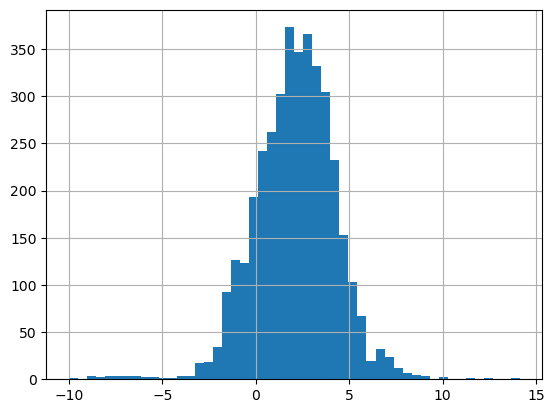

In [58]:
df_clogp["cLogP"].hist(bins=50)

In [59]:
df_clogp.to_csv("/home/ari.ginsparg-umw/df_clogp_with_descriptors.csv", index=False)
df_clogp.to_pickle("/home/ari.ginsparg-umw/df_clogp_with_descriptors.pkl")

In [2]:
##########################################################
##########################################################
#checkpoint if re-opening the notebook
##########################################################
##########################################################
import pandas as pd

df_clogp = pd.read_pickle("/home/ari.ginsparg-umw/df_clogp_with_descriptors.pkl")

print(df_clogp.shape)
df_clogp.head()

(3828, 246)


,ScreenLookup#,LIBRARY,Dead at end?,"DEAD, Sick or Half Dead",SERIOUSLY FLAWED PLATES,ADDITIONAL DEAD/Artifacts,at odds? Meaning the box and column values go in opposite directions.,Extra-Flawed to be flagged (these were noted mostly by hand),artifact flag (post-new sort),REMOVAL LIST,...,MW,cLogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,Fsp3,logD7.4,rdkit_valid
0,2,Ion Channel Ligands,D,1,0.0,0.0,0.0,0.0,0.0,1.0,...,523.630,5.52980,126.68,3,7,7,3,0.551724,5.52980,True
1,3,Ion Channel Ligands,D,1,0.0,0.0,0.0,0.0,0.0,1.0,...,404.504,5.38520,6.48,0,2,6,3,0.230769,5.38520,True
2,4,Ion Channel Ligands,D,1,0.0,0.0,0.0,0.0,0.0,1.0,...,645.319,6.93620,42.68,0,4,11,3,0.400000,6.93620,True
3,5,Ion Channel Ligands,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,...,188.267,2.18250,57.53,2,2,8,0,0.900000,2.18250,True
4,6,Ion Channel Ligands,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,...,245.330,2.16398,73.10,2,3,2,1,0.461538,2.16398,True


<Axes: >

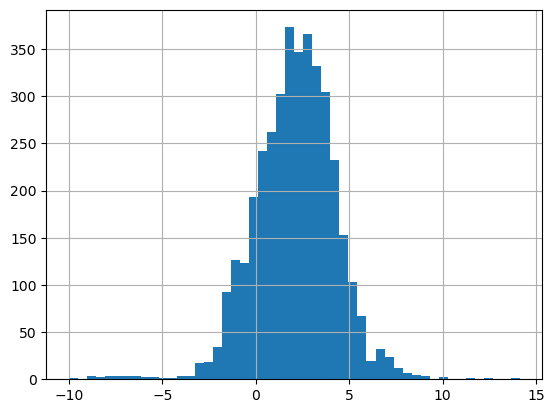

In [3]:
df_clogp["cLogP"].hist(bins=50)

In [4]:
suspicious_df = df_clogp[
    (df_clogp["cLogP"] < -5) | (df_clogp["cLogP"] > 8)
].copy()

print("Number of suspicious compounds:", len(suspicious_df))

Number of suspicious compounds: 44


In [5]:
cols_to_view = [
    "cas_api_name",
    "recovered_smiles",
    "cLogP",
    "recovery_actions"
]

suspicious_df_view = suspicious_df[cols_to_view].copy()
suspicious_df_view.head(50)

,cas_api_name,recovered_smiles,cLogP,recovery_actions
381,Astaxanthin,CC(C=CC=C(C)C=CC1=C(C)C(=O)C(O)CC1(C)C)=CC=CC=...,8.90540,None
964,MK 886,CC(C)c1ccc2c(c1)c(SC(C)(C)C)c(CC(C)(C)C(=O)O)n...,8.01030,None
1125,Paromomycin,NCC1OC(OC2C(CO)OC(OC3C(O)C(N)CC(N)C3OC3OC(CO)C...,-8.86170,None
2066,Dihydrostreptomycin sulfate,CNC1C(OC2C(OC3C(O)C(O)C(NC(=N)N)C(O)C3NC(=N)N)...,-7.94836,largest_organic_fragment_selected
2262,Streptomycin sulfate,CNC1C(OC2C(OC3C(O)C(O)C(NC(=N)N)C(O)C3NC(=N)N)...,-7.74176,largest_organic_fragment_selected
2291,Lactobionic acid,O=C(O)C(O)C(O)C(OC1OC(CO)C(O)C(O)C1O)C(O)CO,-5.66890,None
2316,Probucol,CC(C)(Sc1cc(C(C)(C)C)c(O)c(C(C)(C)C)c1)Sc1cc(C...,9.90830,None
2317,Kanamycin sulfate,NCC1OC(OC2C(N)CC(N)C(OC3OC(CO)C(O)C(N)C3O)C2O)...,-7.29140,largest_organic_fragment_selected
2318,"<span class=""text-smallcaps"">D</smallcap><smal...",Cc1c(C)c2c(c(C)c1O)CCC(C)(CCCC(C)CCCC(C)CCCC(C...,8.84026,None
2333,Amikacin,NCCC(O)C(=O)NC1CC(N)C(OC2OC(CN)C(O)C(O)C2O)C(O...,-8.42420,None


In [6]:
#first analysis, check for fish death vs logp
col_death = "DEAD, Sick or Half Dead"

df_plot = df_clogp.copy()

# ensure numeric + clean
df_plot[col_death] = pd.to_numeric(df_plot[col_death], errors="coerce")

# keep only valid rows
df_plot = df_plot[
    df_plot["cLogP"].notna() &
    df_plot[col_death].isin([0, 1])
].copy()

print(df_plot.shape)
df_plot[[col_death, "cLogP"]].head()

(3828, 246)


,"DEAD, Sick or Half Dead",cLogP
0,1,5.52980
1,1,5.38520
2,1,6.93620
3,0,2.18250
4,0,2.16398


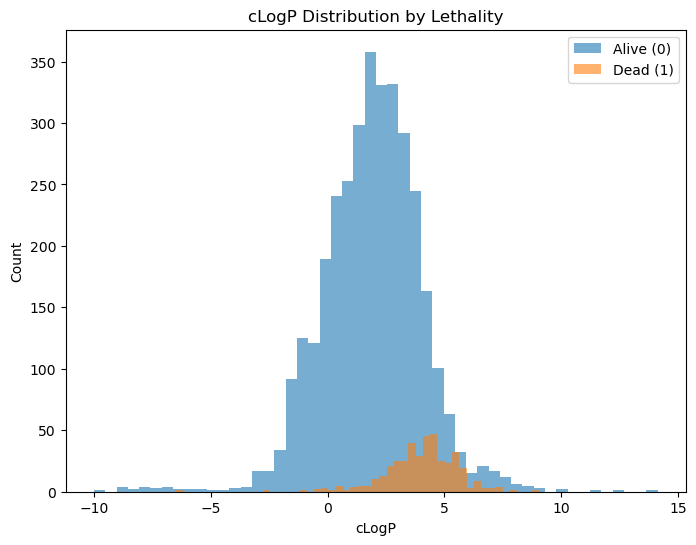

In [7]:
import matplotlib.pyplot as plt

dead = df_plot[df_plot[col_death] == 1]["cLogP"]
alive = df_plot[df_plot[col_death] == 0]["cLogP"]

plt.figure(figsize=(8,6))

plt.hist(alive, bins=50, alpha=0.6, label="Alive (0)")
plt.hist(dead, bins=50, alpha=0.6, label="Dead (1)")

plt.xlabel("cLogP")
plt.ylabel("Count")
plt.title("cLogP Distribution by Lethality")
plt.legend()

plt.show()

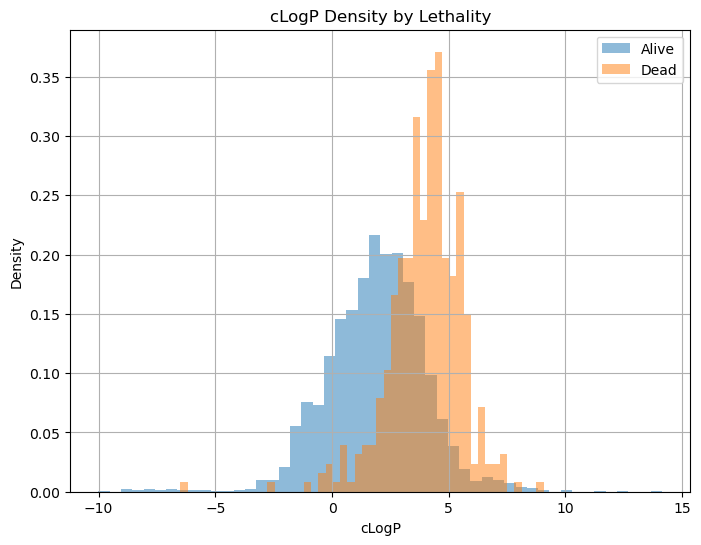

In [8]:
import numpy as np

plt.figure(figsize=(8,6))

alive.hist(bins=50, density=True, alpha=0.5, label="Alive")
dead.hist(bins=50, density=True, alpha=0.5, label="Dead")

plt.xlabel("cLogP")
plt.ylabel("Density")
plt.title("cLogP Density by Lethality")
plt.legend()

plt.show()

Alive mean: 1.8953664571762654
Dead mean: 4.001784127764131
Alive median: 1.9444999999999995
Dead median: 4.168600000000003
Mann-Whitney U p-value: 7.957716928242189e-95
Mean difference (Dead - Alive): 2.106417670587865
           lethality_rate     n
cLogP_bin                      
(-10, -2]        0.023256    86
(-2, 0]          0.012371   485
(0, 2]           0.020000  1200
(2, 4]           0.111271  1393
(4, 6]           0.351687   563
(6, 8]           0.246914    81
(8, 10]          0.125000    16
(10, 20]         0.000000     3


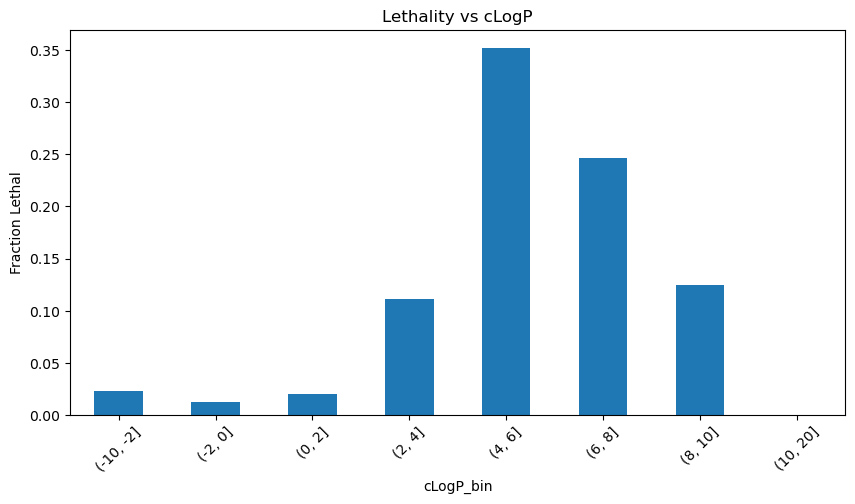

In [9]:
print("Alive mean:", alive.mean())
print("Dead mean:", dead.mean())

print("Alive median:", alive.median())
print("Dead median:", dead.median())

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(alive, dead, alternative="two-sided")

print("Mann-Whitney U p-value:", p)

print("Mean difference (Dead - Alive):", dead.mean() - alive.mean())

df_plot["cLogP_bin"] = pd.cut(
    df_plot["cLogP"],
    bins=[-10, -2, 0, 2, 4, 6, 8, 10, 20]
)

lethality_rate = df_plot.groupby("cLogP_bin")[col_death].mean()
counts = df_plot.groupby("cLogP_bin")[col_death].count()

result = pd.DataFrame({
    "lethality_rate": lethality_rate,
    "n": counts
})

print(result)

result["lethality_rate"].plot(kind="bar", figsize=(10,5))

plt.ylabel("Fraction Lethal")
plt.title("Lethality vs cLogP")
plt.xticks(rotation=45)

plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = df_plot[["cLogP"]]
y = df_plot[col_death]

model = LogisticRegression()
model.fit(X, y)

probs = model.predict_proba(X)[:,1]
auc = roc_auc_score(y, probs)

print("AUC:", auc)

AUC: 0.8127560873833893


In [15]:
#metric analyses
#correspond timepoints to group name suffixes (since those were clobbered in the data sanitization)
timepoint_map = {
    "": "night4",
    ".1": "day5",
    ".2": "night5",
    ".3": "day6"
}

In [16]:
metrics = [
    "TOTAL INACTIVITY (minutes)",
    "TOTAL # BOUTS",
    "AVERAGE SLEEP LENGTH",
    "TIME TO FIRST SLEEP",
    "AVERAGE ACTIVITY/10 MINUTES",
    "AVERAGE ACTIVITY/Active Minute"
]

In [17]:
import matplotlib.pyplot as plt

def plot_logp_vs_metric(df, metric, logp_col="cLogP"):
    plt.figure(figsize=(7,6))
    
    for suffix, label in timepoint_map.items():
        col = metric + suffix
        
        if col not in df.columns:
            continue
        
        x = df[logp_col]
        y = df[col]
        
        mask = x.notna() & y.notna()
        
        plt.scatter(
            x[mask],
            y[mask],
            alpha=0.5,
            label=label
        )
    
    plt.xlabel("cLogP")
    plt.ylabel("Z-score")
    plt.title(f"{metric} vs cLogP")
    plt.legend()
    plt.grid(True)
    
    plt.show()

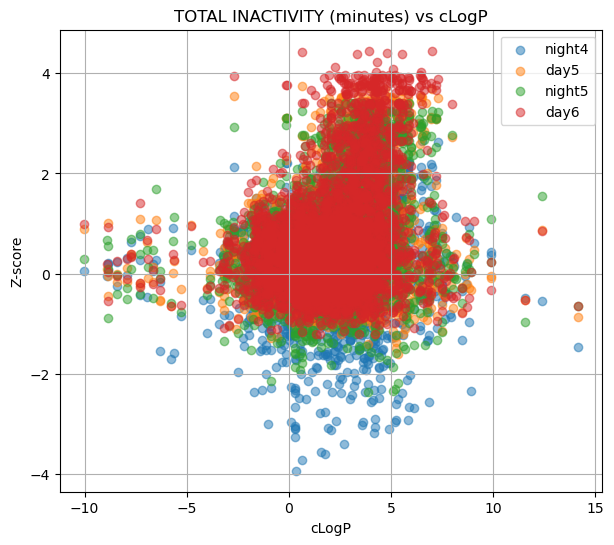

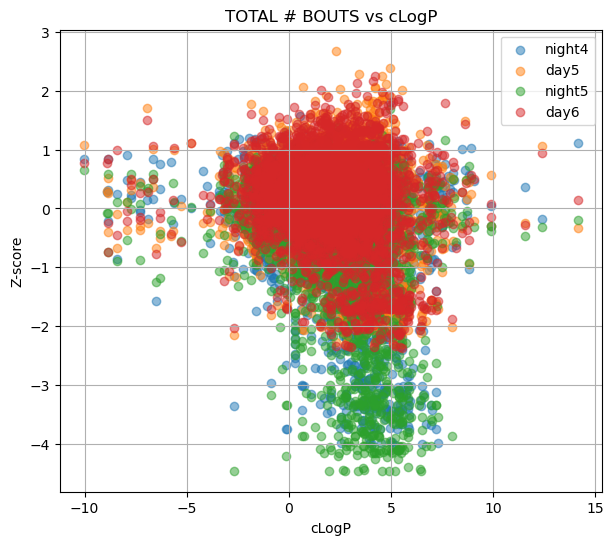

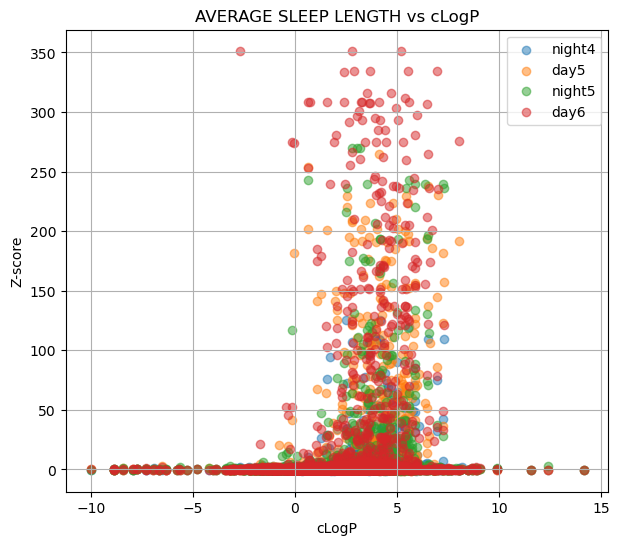

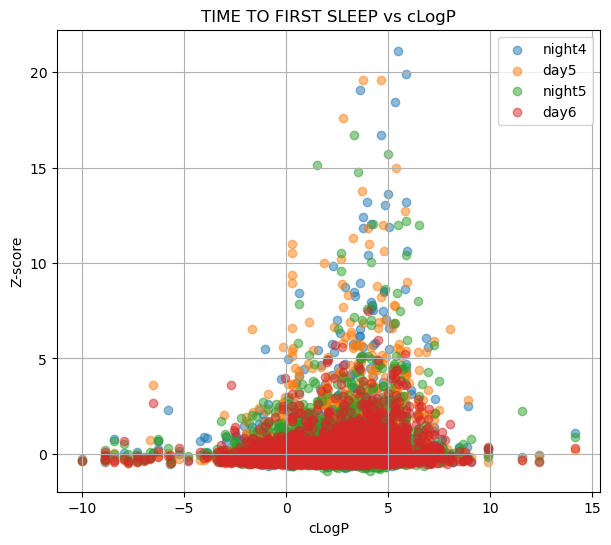

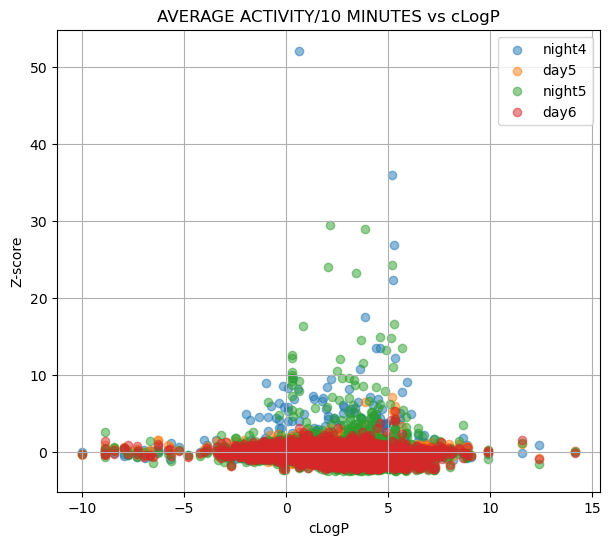

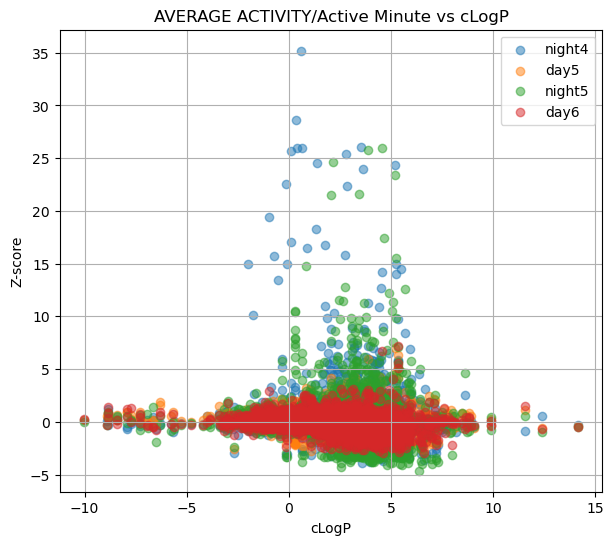

In [18]:
for metric in metrics:
    plot_logp_vs_metric(df_clogp, metric)

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_metric_by_timepoint(df, metric, logp_col="cLogP"):
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    
    for i, (suffix, label) in enumerate(timepoint_map.items()):
        col = metric + suffix
        
        ax = axes[i]
        
        if col not in df.columns:
            ax.set_title(label)
            ax.set_xlabel("cLogP")
            if i == 0:
                ax.set_ylabel("Z-score")
            continue
        
        x = pd.to_numeric(df[logp_col], errors="coerce")
        y = pd.to_numeric(df[col], errors="coerce")
        
        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]
        
        ax.scatter(x, y, alpha=0.5)
        
        if len(x) > 10:
            coeffs = np.polyfit(x.astype(float), y.astype(float), 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = coeffs[0] * x_line + coeffs[1]
            ax.plot(x_line, y_line)
        
        ax.set_title(label)
        ax.set_xlabel("cLogP")
        
        if i == 0:
            ax.set_ylabel("Z-score")
    
    plt.suptitle(metric)
    plt.tight_layout()
    plt.show()

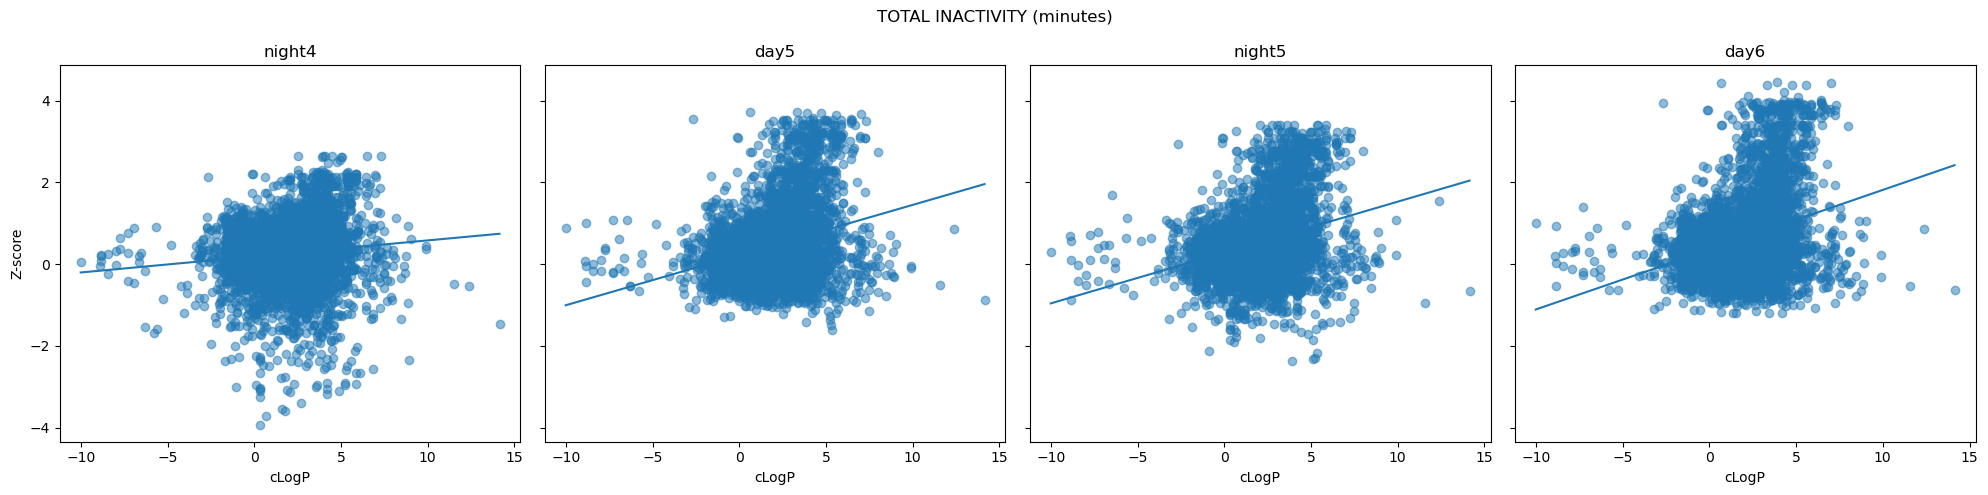

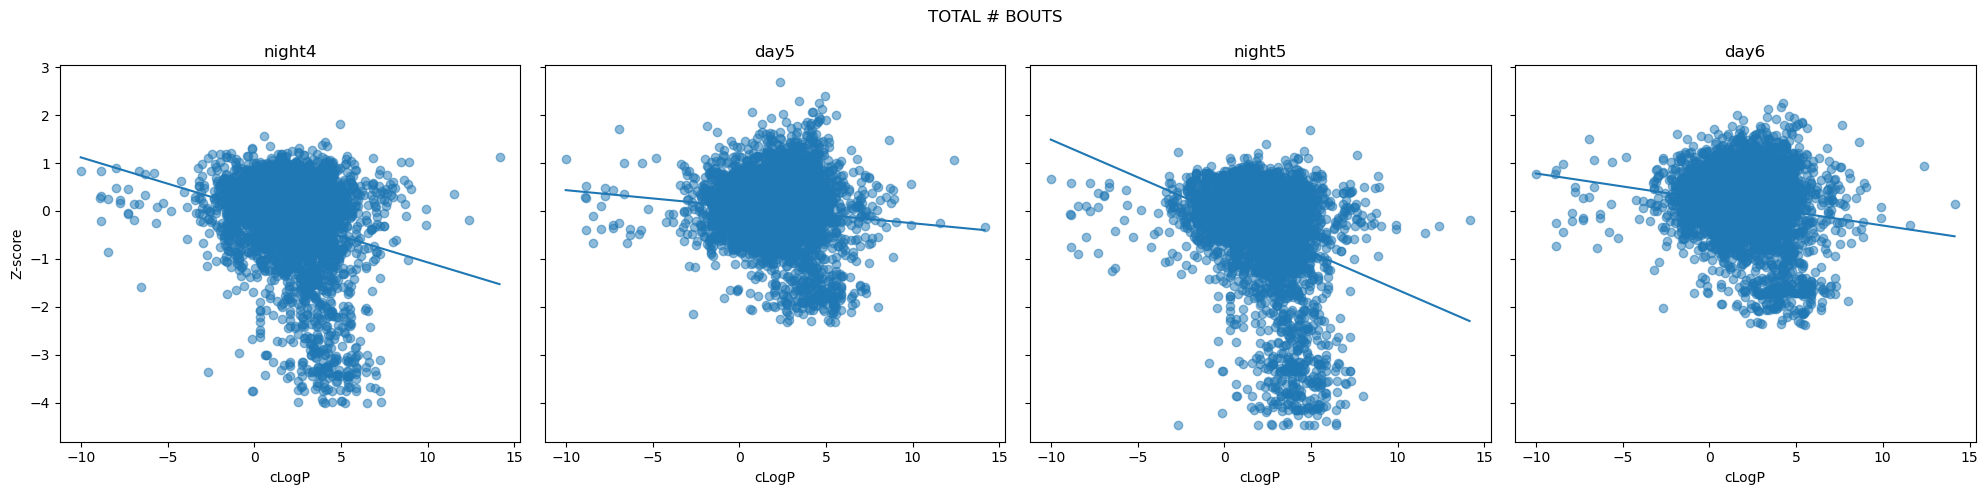

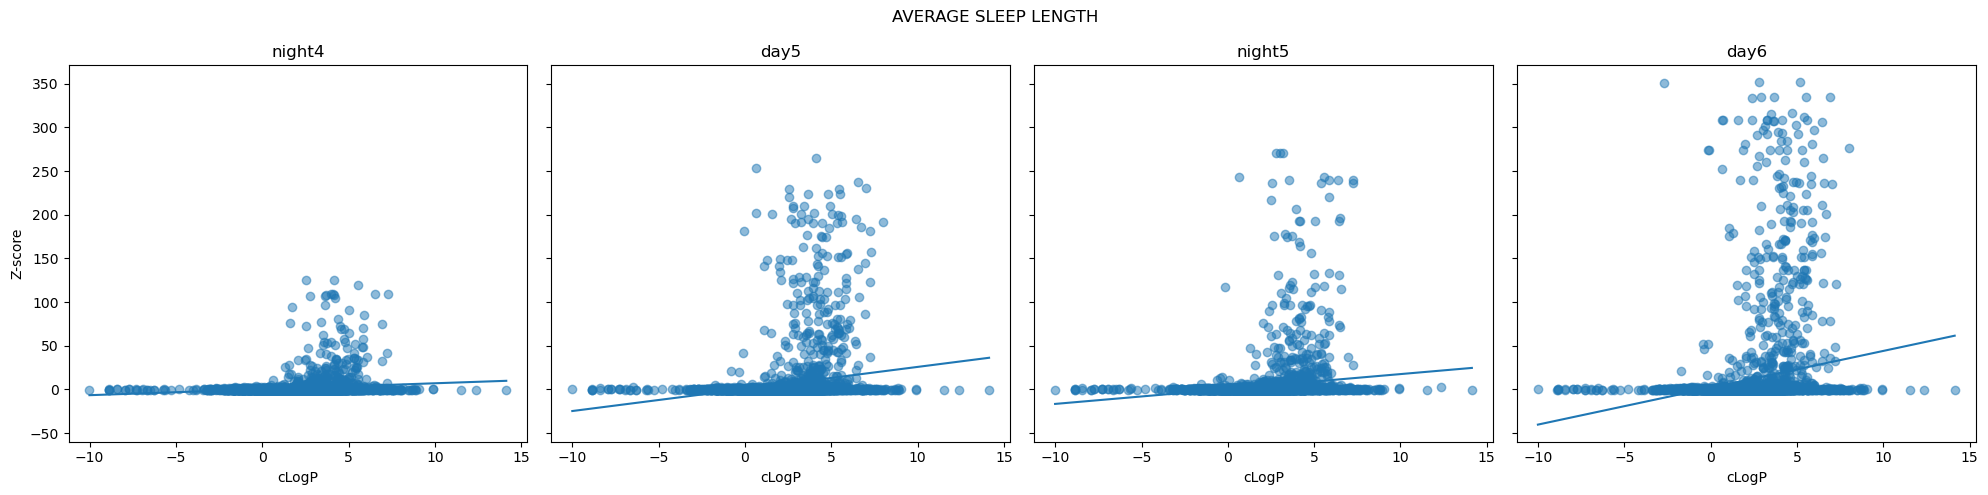

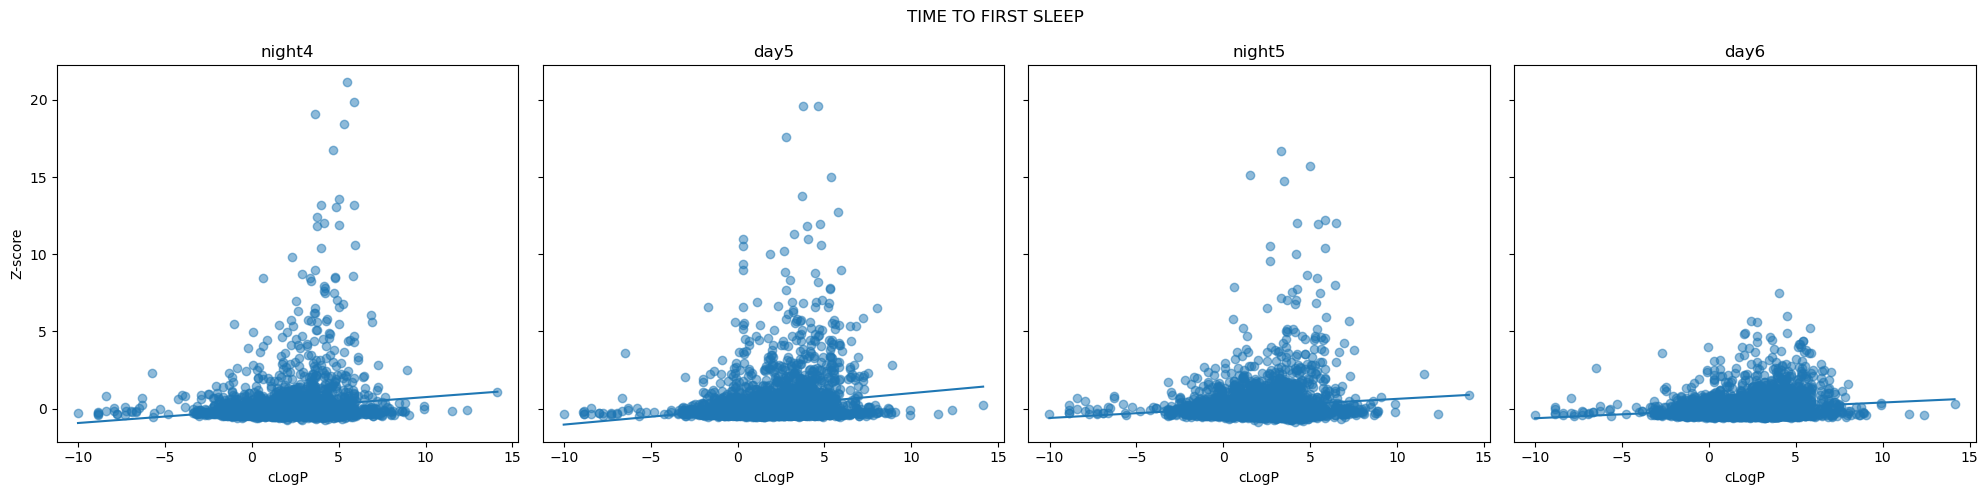

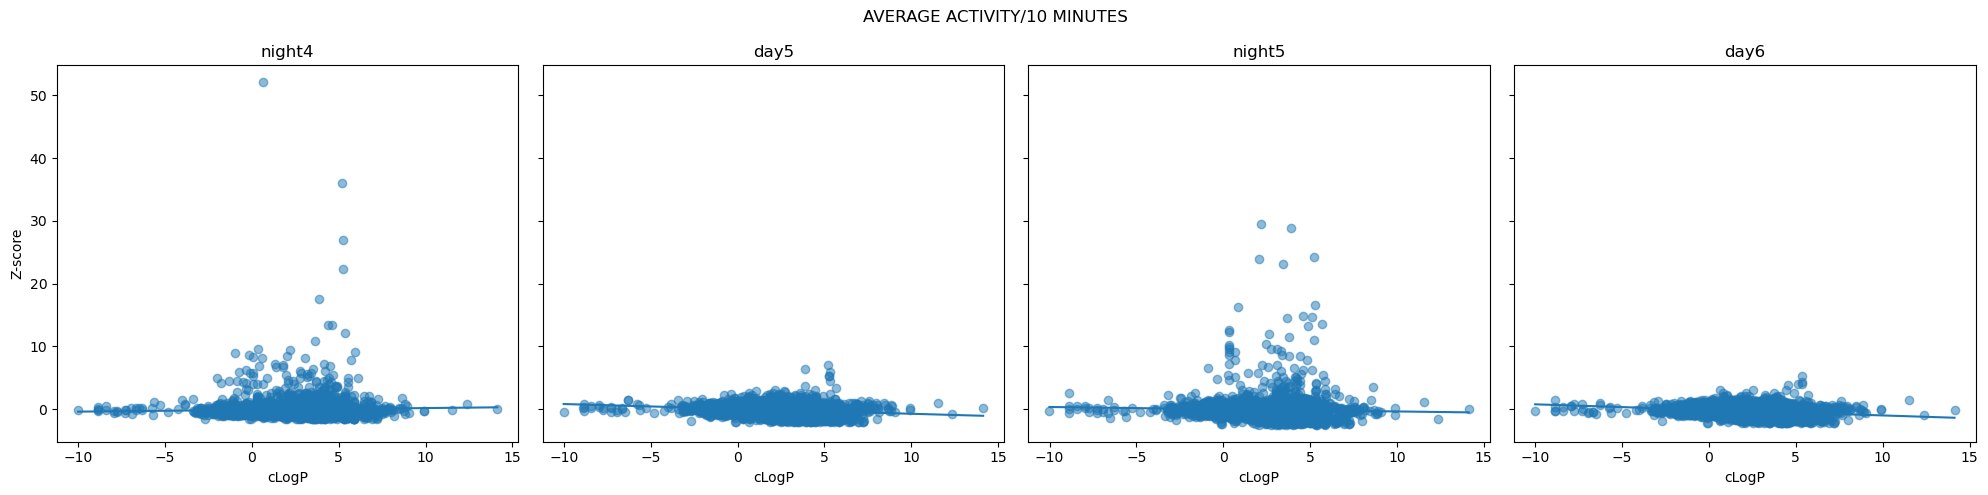

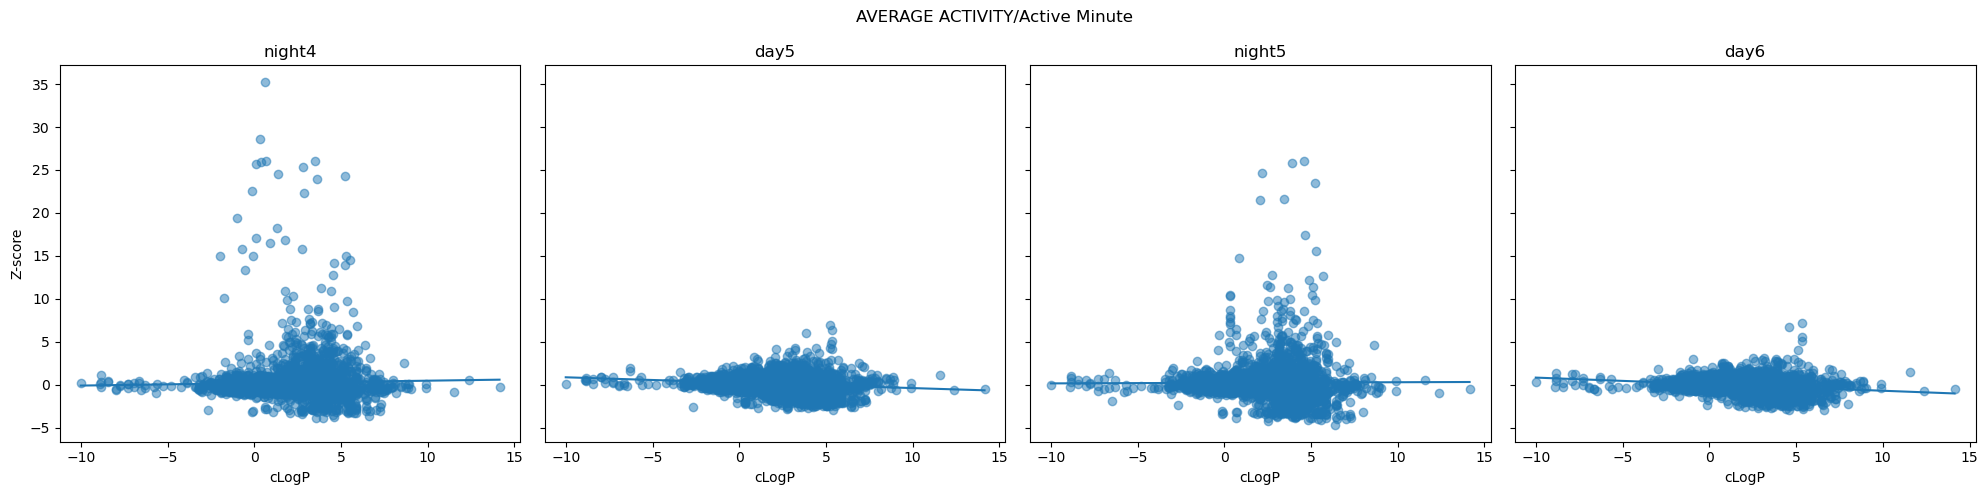

In [22]:
for metric in metrics:
    plot_metric_by_timepoint(df_clogp, metric)

In [23]:
from scipy.stats import spearmanr

def test_logp_correlation(df, metric_col):
    subset = df[["cLogP", metric_col]].dropna()
    
    rho, p = spearmanr(subset["cLogP"], subset[metric_col])
    
    return {
        "rho": rho,
        "p_value": p,
        "n": len(subset)
    }

# example
test_logp_correlation(df_clogp, "TOTAL INACTIVITY (minutes)")

{'rho': 0.11664617012748307, 'p_value': 4.50796968874846e-13, 'n': 3828}

In [26]:
import pandas as pd
import statsmodels.api as sm

def run_regression(df, metric_col):
    subset = df[["cLogP", metric_col]].copy()
    
    subset["cLogP"] = pd.to_numeric(subset["cLogP"], errors="coerce")
    subset[metric_col] = pd.to_numeric(subset[metric_col], errors="coerce")
    
    subset = subset.dropna()
    
    X = sm.add_constant(subset["cLogP"].astype(float))
    y = subset[metric_col].astype(float)
    
    model = sm.OLS(y, X).fit()
    
    return model.summary()

print(run_regression(df_clogp, "TOTAL INACTIVITY (minutes)"))

                                OLS Regression Results                                
Dep. Variable:     TOTAL INACTIVITY (minutes)   R-squared:                       0.011
Model:                                    OLS   Adj. R-squared:                  0.010
Method:                         Least Squares   F-statistic:                     40.70
Date:                        Tue, 24 Mar 2026   Prob (F-statistic):           1.99e-10
Time:                                16:25:13   Log-Likelihood:                -4709.8
No. Observations:                        3828   AIC:                             9424.
Df Residuals:                            3826   BIC:                             9436.
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [27]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import statsmodels.api as sm

def analyze_metric(df, x_col, y_col):
    subset = df[[x_col, y_col]].copy()
    
    subset[x_col] = pd.to_numeric(subset[x_col], errors="coerce")
    subset[y_col] = pd.to_numeric(subset[y_col], errors="coerce")
    
    subset = subset.dropna()
    
    if len(subset) < 10:
        return None
    
    x = subset[x_col]
    y = subset[y_col]
    
    # Spearman
    rho, spearman_p = spearmanr(x, y)
    
    # Regression
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    
    coef = model.params[x_col]
    reg_p = model.pvalues[x_col]
    r2 = model.rsquared
    
    return {
        "n": len(subset),
        "spearman_rho": rho,
        "spearman_p": spearman_p,
        "reg_coef": coef,
        "reg_p": reg_p,
        "r_squared": r2
    }

In [28]:
results = []

for metric in metrics:
    for suffix, label in timepoint_map.items():
        col = metric + suffix
        
        if col not in df_clogp.columns:
            continue
        
        res = analyze_metric(df_clogp, "cLogP", col)
        
        if res is None:
            continue
        
        res["metric"] = metric
        res["timepoint"] = label
        res["column"] = col
        
        results.append(res)

df_results = pd.DataFrame(results)

In [29]:
df_results = df_results[[
    "metric",
    "timepoint",
    "n",
    "spearman_rho",
    "spearman_p",
    "reg_coef",
    "reg_p",
    "r_squared"
]]

In [31]:
df_results.sort_values("spearman_rho", key=abs, ascending=False).head(40)

,metric,timepoint,n,spearman_rho,spearman_p,reg_coef,reg_p,r_squared
6,TOTAL # BOUTS,night5,3828,-0.302361,9.451955e-82,-0.156891,1.133044e-89,0.100023
2,TOTAL INACTIVITY (minutes),night5,3828,0.284243,4.614397e-72,0.124446,1.013861e-74,0.083722
19,AVERAGE ACTIVITY/10 MINUTES,day6,3828,-0.274608,3.403050e-67,-0.088543,1.174988e-53,0.060274
1,TOTAL INACTIVITY (minutes),day5,3828,0.261292,8.719946e-61,0.122802,2.265108e-68,0.076714
3,TOTAL INACTIVITY (minutes),day6,3828,0.260843,1.413640e-60,0.146277,5.366601e-77,0.086222
10,AVERAGE SLEEP LENGTH,night5,3828,0.256459,1.502343e-58,1.706699,3.635584e-27,0.030002
17,AVERAGE ACTIVITY/10 MINUTES,day5,3828,-0.246187,5.937196e-54,-0.077608,6.609430e-37,0.041230
11,AVERAGE SLEEP LENGTH,day6,3828,0.243819,6.357999e-53,4.215298,6.713793e-38,0.042369
23,AVERAGE ACTIVITY/Active Minute,day6,3828,-0.234627,4.961401e-49,-0.076440,3.010598e-38,0.042768
9,AVERAGE SLEEP LENGTH,day5,3828,0.224737,4.996467e-45,2.524872,2.615119e-37,0.041692


In [32]:
df_results.sort_values("r_squared", ascending=False).head(40)

,metric,timepoint,n,spearman_rho,spearman_p,reg_coef,reg_p,r_squared
6,TOTAL # BOUTS,night5,3828,-0.302361,9.451955e-82,-0.156891,1.133044e-89,0.100023
3,TOTAL INACTIVITY (minutes),day6,3828,0.260843,1.413640e-60,0.146277,5.366601e-77,0.086222
2,TOTAL INACTIVITY (minutes),night5,3828,0.284243,4.614397e-72,0.124446,1.013861e-74,0.083722
1,TOTAL INACTIVITY (minutes),day5,3828,0.261292,8.719946e-61,0.122802,2.265108e-68,0.076714
4,TOTAL # BOUTS,night4,3828,-0.210157,1.808437e-39,-0.109665,1.468978e-54,0.061291
19,AVERAGE ACTIVITY/10 MINUTES,day6,3828,-0.274608,3.403050e-67,-0.088543,1.174988e-53,0.060274
23,AVERAGE ACTIVITY/Active Minute,day6,3828,-0.234627,4.961401e-49,-0.076440,3.010598e-38,0.042768
11,AVERAGE SLEEP LENGTH,day6,3828,0.243819,6.357999e-53,4.215298,6.713793e-38,0.042369
9,AVERAGE SLEEP LENGTH,day5,3828,0.224737,4.996467e-45,2.524872,2.615119e-37,0.041692
17,AVERAGE ACTIVITY/10 MINUTES,day5,3828,-0.246187,5.937196e-54,-0.077608,6.609430e-37,0.041230


In [33]:
df_results["spearman_sig"] = df_results["spearman_p"] < 0.05
df_results["reg_sig"] = df_results["reg_p"] < 0.05

In [34]:
df_results["spearman_rho"] = df_results["spearman_rho"].round(3)
df_results["reg_coef"] = df_results["reg_coef"].round(3)
df_results["r_squared"] = df_results["r_squared"].round(4)
df_results["spearman_p"] = df_results["spearman_p"].apply(lambda x: f"{x:.2e}")
df_results["reg_p"] = df_results["reg_p"].apply(lambda x: f"{x:.2e}")

In [35]:
pivot_rho = df_results.pivot(
    index="metric",
    columns="timepoint",
    values="spearman_rho"
)

pivot_r2 = df_results.pivot(
    index="metric",
    columns="timepoint",
    values="r_squared"
)

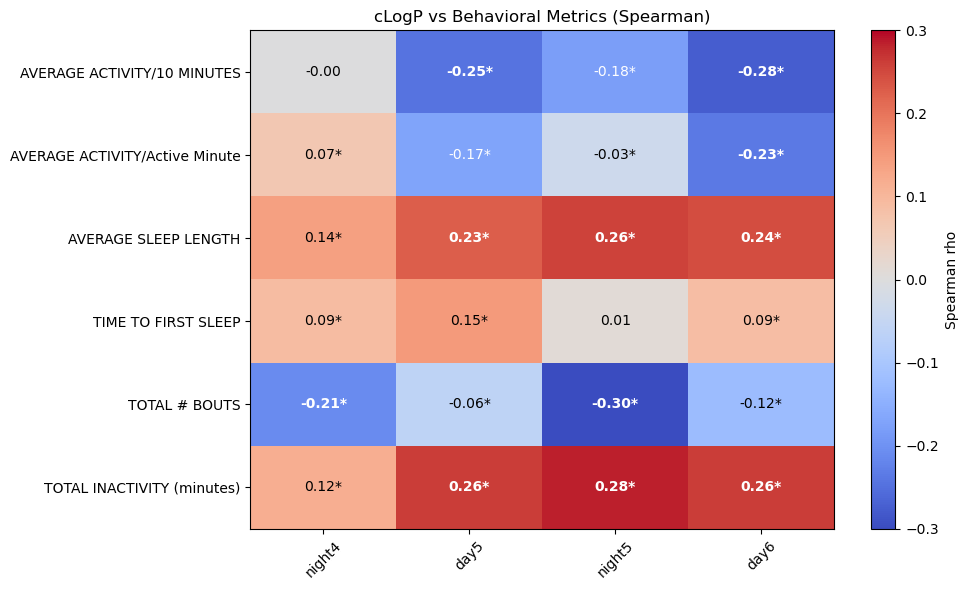

In [43]:
pivot_p = df_results.pivot(
    index="metric",
    columns="timepoint",
    values="spearman_p"
)

desired_order = ["night4", "day5", "night5", "day6"]
pivot_rho = pivot_rho[desired_order]
pivot_p = pivot_p[desired_order]

plt.figure(figsize=(10,6))

im = plt.imshow(pivot_rho, aspect="auto", vmin=-0.3, vmax=0.3, cmap="coolwarm")

plt.colorbar(im, label="Spearman rho")

plt.xticks(range(len(pivot_rho.columns)), pivot_rho.columns, rotation=45)
plt.yticks(range(len(pivot_rho.index)), pivot_rho.index)

# Add annotations
for i in range(pivot_rho.shape[0]):
    for j in range(pivot_rho.shape[1]):
        val = pivot_rho.iloc[i, j]
        pval = pivot_p.iloc[i, j]  # <-- make sure this exists
        
        # significance marker
        star = "*" if float(pval) < 0.05 else ""
        
        # effect size emphasis
        weight = "bold" if abs(val) > 0.2 else "normal"
        
        # optional: improve contrast
        text_color = "white" if abs(val) > 0.15 else "black"
        
        plt.text(
            j, i,
            f"{val:.2f}{star}",
            ha="center",
            va="center",
            color=text_color,
            fontweight=weight
        )

plt.title("cLogP vs Behavioral Metrics (Spearman)")
plt.tight_layout()
plt.show()